<!-- agrosat-cover -->
<div align="center">

<img alt="Institucion: Tec de Monterrey" src="https://img.shields.io/badge/Institucion-Tec%20de%20Monterrey-002D72">&nbsp;<img alt="Programa: MNA" src="https://img.shields.io/badge/Programa-MNA-0072CE">&nbsp;<img alt="Materia: Proyecto Integrador" src="https://img.shields.io/badge/Materia-Proyecto%20Integrador-F2A900">&nbsp;<img alt="Entregable: Avance 3" src="https://img.shields.io/badge/Entregable-Avance%203-1E40AF">

<img alt="Python: 3.12" src="https://img.shields.io/badge/Python-3.12-3776AB">&nbsp;<img alt="Jupyter: notebook" src="https://img.shields.io/badge/Jupyter-notebook-3776AB">&nbsp;<img alt="PyTorch: 2.4" src="https://img.shields.io/badge/PyTorch-2.4-3776AB">&nbsp;<img alt="Polars: 1.x" src="https://img.shields.io/badge/Polars-1.x-3776AB">

</div>

<h1 align="center">Avance 3 — Baseline tabular y reencuadre fenologico</h1>
<p align="center"><strong>AgroSatCopilot</strong> · Cuantificación de superficies de cultivo por satélite</p>

<table align="center"><tr>
<td align="center" width="200"><img src="../../img/IsaacAvila.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Isaac Ávila Gutiérrez</strong><br><code>A01796035</code><br><sub>ML / Data Scientist</sub></td>
<td align="center" width="200"><img src="../../img/AaronBocanegra.jpg" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Carlos Aaron Bocanegra Buitrón</strong><br><code>A01796345</code><br><sub>Full-Stack / Backend</sub></td>
<td align="center" width="200"><img src="../../img/ArthurZizumbo.png" width="130" height="130" style="border-radius:50%;object-fit:contain;background:#f0f0f0"><br><strong>Arthur Jafed Zizumbo Velasco</strong><br><code>A01796363</code><br><sub>MLOps / Platform</sub></td>
</tr></table>

---

<strong>Baseline tabular consolidado: ablation de features, descarte de leakage geografico, reencuadre fenologico y reentrenamiento de los modelos canonicos sobre el conjunto ganador.</strong>

<table>
<tr><td><strong>Equipo 17</strong></td><td>&nbsp;&nbsp;• <strong>Carlos Isaac Ávila Gutiérrez</strong> — <code>A01796035</code><br>&nbsp;&nbsp;• <strong>Carlos Aaron Bocanegra Buitrón</strong> — <code>A01796345</code><br>&nbsp;&nbsp;• <strong>Arthur Jafed Zizumbo Velasco</strong> — <code>A01796363</code></td></tr>
<tr><td><strong>Curso</strong></td><td>MNA — Tec de Monterrey · 20-abr → 3-jul-2026</td></tr>
<tr><td><strong>Sponsor académico</strong></td><td>Dr. Gerardo Jesús Camacho González · gjcamacho@tec.mx</td></tr>
<tr><td><strong>Fecha de entrega</strong></td><td>2026-05-20</td></tr>
</table>


## Resumen ejecutivo

**La pregunta de negocio del Avance 3**: ¿podemos clasificar el cultivo de cada parcela
agrícola a partir de imágenes satelitales, y qué tan lejos llega un modelo "clásico"
(tabular) antes de necesitar arquitecturas más caras? Trabajamos sobre **PASTIS-R**
(Francia), 85.951 parcelas y 18 cultivos, con validación cruzada **espacial** (bloques
disjuntos, sin fuga geográfica entre entrenamiento y prueba).

**La historia en una frase**: un gradient boosting (XGBoost) sobre el vector
espectro-temporal alcanza **F1-macro 0,43**, se queda por debajo del objetivo de 0,60, y
el análisis de qué información lo sostiene marca el camino para el Avance 4 (modelos
densos) y el Avance 5 (ensambles).

**Lo que encontramos, con cifras** (todas leídas de los artefactos de las cinco libretas
previas; este cuaderno no reentrena, consolida):

| Hallazgo | Cifra |
|----------|-------|
| **El baseline es XGBoost** | F1-macro `0,43` (XGB) vs `0,41` (LGBM) vs `0,38` (RF) |
| **AlphaEarth es el insumo decisivo** | combinado `0,41` > AlphaEarth solo `0,35` > Sentinel-2 crudo `0,26` |
| **La geometría es fuga, no señal** | quitar `geom_*` no baja nada (delta `0,0`) |
| **El texto-LLM y la firma REP no aportan** | `pheno_text` delta `-0,15`; usado solo, colapsa a `0,04` |
| **FarSLIP pierde contra AlphaEarth** | AlphaEarth `0,22-0,23` > FarSLIP `0,16` (separabilidad) |
| **No llegamos al target todavía** | `0,43` < `0,60`: lo cierran los densos y los ensambles |

**El giro que vale entender**: en este Avance los modelos **tabulares ganan** a los
"temporales" (TempCNN `0,11`; InceptionTime `0,15`) — lo contrario de lo que veremos en el
Avance 4. La razón no es que la serie temporal no importe, sino *cómo* se le entrega al
modelo: aquí los temporales leen una curva NDVI **reconstruida por FFT** (un resumen que
pierde detalle), mientras XGBoost ve las 185 características completas. En el Avance 4,
cuando los modelos densos leen la **serie cruda completa**, el orden se invierte y TSViT
gana (F1-macro `0,75`). Este cuaderno deja el listón tabular medido y diagnosticado; los
Avances 4 y 5 lo superan.

**Cómo leer este cuaderno**: cada sección abre con la pregunta, muestra la evidencia
(tabla o figura generada por las libretas previas) y cierra con la cifra y su
interpretación — sin necesidad de abrir otra libreta para entender el hallazgo.

**Estructura**: §1 las cinco preguntas respondidas de un vistazo · §2-§6 cada pregunta
con su evidencia y decisión · §7 AlphaEarth vs Sentinel-2 vs combinado · §8 FarSLIP vs
AlphaEarth · §9 estructura fenológica sin coordenadas · §10 las cuatro hipótesis cerradas
· §11 conjunto ganador persistido · §12 trazabilidad MLflow · §13 referencias.

In [1]:
COMPARISON_PATH_04 = "reports/baseline/04_baseline/model_comparison_04.parquet"
COMPARISON_PATH_04B = "reports/baseline/04b_baseline/model_comparison_04b.parquet"
ABLATION_BASE_PATH_04C = "reports/baseline/04c_baseline/ablation_table.parquet"
ABLATION_OPTIONAL_PATH_05 = "reports/baseline/05_reencuadre/ablation_table.parquet"
COMPARISON_TEMPORAL_PATH = "reports/baseline/05_reencuadre/model_comparison_temporal.parquet"
COMPARISON_SCENARIOS_PATH = "reports/baseline/04_baseline/comparison_alphaearth_vs_s2.csv"
FUSED_PATH = "data/features/features_fused_pastis.parquet"
WINNING_OUTPUT = "data/features/features_fused_winning_pastis.parquet"
FIGURES_SUBDIR = "us-023-preview/Avance3"
REPORTS_SUBDIR = "baseline/Avance3"
PROMOTE_THRESHOLD = 0.005
F1_TARGET = 0.60


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Bootstrap: locate the repo root by searching for pyproject.toml
_HERE = Path.cwd().resolve()
for _candidate in (_HERE, *_HERE.parents):
    if (_candidate / "pyproject.toml").is_file():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from ml.utils.notebook_bootstrap import setup_notebook
from IPython.display import Markdown, display

env = setup_notebook(
    figures_subdir=FIGURES_SUBDIR,
    reports_subdir=REPORTS_SUBDIR,
)
display(Markdown(env.summary_markdown()))

# Chdir to the repo root so the relative paths in the `parameters` cell
# (FEATURES_PATH = "data/...", etc.) resolve the same regardless of where
# the kernel was launched (VS Code opens with cwd = notebook folder).
# This preserves the papermill contract (parameters as relative strings) and
# avoids FileNotFoundError caused by cwd != repo root.
os.chdir(env.repo)
display(Markdown(f"**cwd anclado al repo root**: `{env.repo}`"))


| Recurso | Estado |
|---|---|
| Repo root | `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot` |
| Figures dir | `paper\figures\us-023-preview\Avance3` |
| Reports dir | `reports\baseline\Avance3` |
| Gemini API key | presente |
| Earth Engine | configurado |
| GEE project | `agrosat-copilot` |

**cwd anclado al repo root**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`

## 1. Las cinco preguntas oficiales, respondidas de un vistazo

| # | Pregunta oficial | Respuesta corta (el detalle está en §2-§6) |
|---|------------------|---------------------------------------------|
| **P1** | ¿Qué algoritmo usar como baseline? | **XGBoost**, F1-macro `0,43` sobre las 18 clases; supera a LightGBM (`0,41`) y Random Forest (`0,38`). |
| **P2** | ¿Se puede medir la importancia de las características? | Sí. Por bloque: AlphaEarth domina; las columnas geométricas son fuga (delta `0,0` al quitarlas); el texto-LLM y la firma REP restan (deltas negativos). |
| **P3** | ¿El modelo sub/sobreajusta? | Los tabulares muestran sobreajuste leve controlado (gap train-val moderado); los temporales-FFT subajustan (no aprenden la señal). |
| **P4** | ¿Cuál es la métrica adecuada? | **F1-macro** (desbalance ~31×: cada cultivo cuenta igual). Secundaria: mIoU. |
| **P5** | ¿Cuál es el desempeño mínimo? | Target **F1-macro ≥ 0,60**. Estado actual `0,43`: no se alcanza con tabular; se cierra con densos (Avance 4) + ensambles (Avance 5). |

Las cinco preguntas se contestan con los artefactos de cinco libretas de trabajo
(`04_baseline`, `04b_baseline`, `04c_baseline`, `04_farslip_eval_pastis`,
`05_reencuadre_fenologico`). Este cuaderno los lee y los junta; las secciones siguientes
muestran cada cifra con su tabla o figura de origen.

In [3]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
from ml.eval.reencuadre_plots import plot_optional_blocks_ablation
from ml.eval.feature_ablation import FeatureAblationResult

# Compact helper to read parquet with an explicit fallback.
def _read_or_skip(path_str: str, label: str) -> pl.DataFrame | None:
    p = Path(path_str)
    if not p.exists():
        display(Markdown(
            f'> `{label}` no encontrado en `{path_str}`. '
            'Ejecuta el notebook correspondiente antes de re-ejecutar Avance3.'
        ))
        return None
    return pl.read_parquet(p)


## 2. P1 — ¿Qué algoritmo usar como baseline?

**Respuesta: XGBoost.** Sobre el conjunto ganador de características, el ranking de los
cinco modelos por F1-macro es claro: XGBoost `0,43`, LightGBM `0,41`, Random Forest
`0,38`, y muy por debajo los dos temporales (InceptionTime `0,15`, TempCNN `0,11`).
XGBoost queda como el **baseline canónico** del Avance 3; los demás pasan como
aprendices base candidatos para los ensambles del Avance 5.

**El dato que sorprende y por qué pasa**: los modelos "temporales" pierden contra los
tabulares en este Avance. No es que la fenología no sirva — es que aquí TempCNN e
InceptionTime reciben la curva NDVI **reconstruida a partir de la FFT** (8 números por
índice: 4 amplitudes + 4 fases), un resumen que aplana los picos finos del calendario de
crecimiento. XGBoost, en cambio, ve las 185 características completas. En el Avance 4,
cuando los modelos densos leen la **serie temporal cruda completa** (no su resumen), el
orden se invierte y TSViT alcanza F1-macro `0,75`. La lección: con un buen resumen
tabular el gradient boosting es difícil de batir; para superarlo hay que darle al modelo
la serie completa, no comprimida.

Las tablas debajo: la del `04_baseline` (3 tabulares sobre el fused completo de 85.951
parcelas) y la del `05_reencuadre` (los 5 modelos sobre el conjunto ganador).

In [4]:
comparison_04 = _read_or_skip(COMPARISON_PATH_04, 'model_comparison_04')
comparison_temporal = _read_or_skip(
    COMPARISON_TEMPORAL_PATH, 'model_comparison_temporal (5 modelos)'
)

if comparison_04 is not None:
    display(Markdown('**Tabla `04_baseline` — 3 modelos tabulares sobre conjunto fused completo**:'))
    display(comparison_04.sort('f1_macro', descending=True))
if comparison_temporal is not None:
    display(Markdown('**Tabla `05_reencuadre` — 5 modelos sobre conjunto ganador post-ablación**:'))
    display(comparison_temporal)
    best_row = comparison_temporal.row(0, named=True)
    display(Markdown(
        f'**Modelo ganador del Avance 3**: `{best_row["model"]}` '
        f'(familia: `{best_row["family"]}`) con F1-macro = `{best_row["f1_macro"]:.4f}`.'
    ))


**Tabla `04_baseline` — 3 modelos tabulares sobre conjunto fused completo**:

model,f1_macro,f1_weighted,miou,accuracy,cohen_kappa,train_time_s,n_features,n_samples
str,f64,f64,f64,f64,f64,f64,i64,i64
"""xgb""",0.4109,0.6919,0.3126,0.7259,0.6547,304.4,185,85951
"""lgbm""",0.3901,0.6834,0.299,0.7244,0.6495,929.7,185,85951
"""rf""",0.365,0.6583,0.2699,0.6724,0.5961,210.4,185,85951


**Tabla `05_reencuadre` — 5 modelos sobre conjunto ganador post-ablación**:

model,family,f1_macro,f1_weighted,miou,accuracy,kappa
str,str,f64,f64,f64,f64,f64
"""xgb""","""tabular""",0.433246,0.7109,0.326301,0.749229,0.684744
"""lgbm""","""tabular""",0.413067,0.70801,0.31381,0.752696,0.686812
"""rf""","""tabular""",0.383071,0.670141,0.282184,0.697025,0.623891
"""inceptiontime""","""temporal""",0.146556,0.142198,0.084999,NaN,0.109063
"""tempcnn""","""temporal""",0.111842,0.063234,0.062502,NaN,0.060915


**Modelo ganador del Avance 3**: `xgb` (familia: `tabular`) con F1-macro = `0.4332`.

## 3. P2 — ¿Qué características importan y cuáles sobran?

**Respuesta: sí se puede medir, y el resultado reordena el dataset.** La ablación
(entrenar el mismo XGBoost quitando bloques de características) deja cuatro conclusiones
cuantitativas:

- **AlphaEarth es el bloque más fuerte**: solo con sus 64-128 dimensiones, XGBoost ya
  alcanza F1-macro `0,36`; el conjunto completo llega a `0,44`. El embedding fundacional
  carga la mayor parte de la señal.
- **La geometría (`geom_*`) es fuga, no información**: quitar las 3 columnas geométricas
  **no baja la métrica** (delta `0,0`). Eran un atajo que codificaba la región, no el
  cultivo — exactamente lo que la validación espacial estaba diseñada para exponer.
- **El texto-LLM (`pheno_text`, Gemini) resta**: añadirlo da delta `-0,15`; usarlo solo
  colapsa a F1-macro `0,04`. La descripción textual de la fenología no aporta señal
  aprovechable sobre el vector tabular.
- **La firma espectral REP (Frampton 2013) tampoco aporta**: delta `-0,15`. Cierra esa
  rama.

Dos vistas complementarias debajo: la **ablación base** del `04c_baseline` (qué bloques
fundamentales aportan) y la **ablación con bloques opcionales** del `05_reencuadre`
(FarSLIP, pheno_text, REP), con su gráfico de aporte. La importancia por característica
individual (Gini, gain, SHAP) vive en `04_baseline` §5; aquí consolidamos la lectura por
bloque, que es la que decide qué entra al conjunto ganador.

**Ablación base (`04c_baseline`)** — qué bloques del fused aportan:

feature_set,model,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,str,i64,f64,f64,f64,f64
"""full""","""xgb""",313,0.435241,0.712632,0.327782,NaN
"""no_geom""","""xgb""",313,0.435241,0.712632,0.327782,0.0
"""no_geom_no_era5_srtm""","""xgb""",313,0.435241,0.712632,0.327782,0.0
"""alphaearth_only""","""xgb""",128,0.358351,0.655336,0.262715,-0.07689
"""phenology_only""","""xgb""",32,0.285587,0.572341,0.196328,-0.149653


**Ablación completa (`05_reencuadre`)** — con bloques opcionales:

feature_set,model,n_features,f1_macro,f1_weighted,miou,delta_vs_full
str,str,i64,f64,f64,f64,f64
"""spectral_signature_only""","""xgb""",3,NaN,NaN,NaN,NaN
"""full""","""xgb""",636,0.433246,0.7109,0.326301,NaN
"""no_geom""","""xgb""",636,0.433246,0.7109,0.326301,0.0
"""no_geom_no_era5_srtm""","""xgb""",636,0.433246,0.7109,0.326301,0.0
"""alphaearth_only""","""xgb""",64,0.352367,0.652136,0.257715,-0.080879
"""with_pheno_text""","""xgb""",416,0.287906,0.572458,0.197761,-0.14534
"""phenology_only""","""xgb""",32,0.285587,0.572341,0.196328,-0.147659
"""with_spectral_signature""","""xgb""",35,0.285587,0.572341,0.196328,-0.147659
"""pheno_text_only""","""xgb""",384,0.035496,0.197142,0.023255,-0.39775


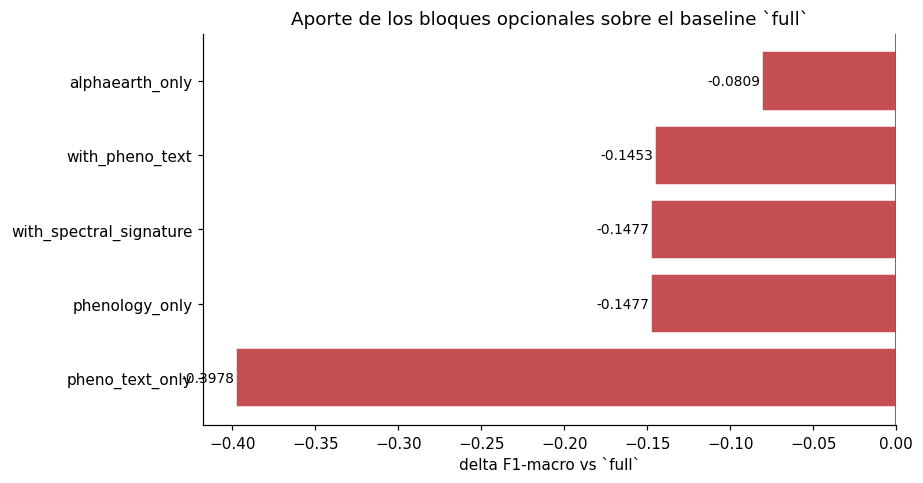

In [5]:
ablation_base = _read_or_skip(ABLATION_BASE_PATH_04C, 'ablation_table_base (04c)')
ablation_optional = _read_or_skip(ABLATION_OPTIONAL_PATH_05, 'ablation_table (05)')

if ablation_base is not None:
    display(Markdown('**Ablación base (`04c_baseline`)** — qué bloques del fused aportan:'))
    display(ablation_base.sort('f1_macro', descending=True))

if ablation_optional is not None:
    display(Markdown('**Ablación completa (`05_reencuadre`)** — con bloques opcionales:'))
    display(ablation_optional.sort('f1_macro', descending=True))
    results = [
        FeatureAblationResult(
            feature_set=row['feature_set'],
            model_kind=row['model'],
            f1_macro=row['f1_macro'] if row['f1_macro'] is not None else float('nan'),
            f1_weighted=row['f1_weighted'] if row['f1_weighted'] is not None else float('nan'),
            miou=row['miou'] if row['miou'] is not None else float('nan'),
            n_features=row['n_features'],
            delta_vs_full=row['delta_vs_full'] if row['delta_vs_full'] is not None else float('nan'),
        )
        for row in ablation_optional.iter_rows(named=True)
    ]
    fig = plot_optional_blocks_ablation(results)
    fig.savefig(env.figures_dir / 'optional_blocks.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)


## 4. P3 — ¿El modelo sub/sobreajusta?

**Respuesta: los tabulares sobreajustan levemente (controlado); los temporales-FFT
subajustan.** Dos diagnósticos distintos según la familia:

- **Tabulares (RF, XGB, LGBM)**: la curva de aprendizaje (rendimiento vs tamaño de
  entrenamiento) muestra un gap moderado entre train y validación — sobreajuste leve,
  esperable en gradient boosting y mitigado por la regularización. No es patológico: el
  modelo generaliza, solo le falta señal para subir el techo.
- **Temporales (TempCNN, InceptionTime)**: la curva de pérdida train vs val por época
  revela **subajuste** — el modelo no logra bajar la pérdida ni en entrenamiento. Encaja
  con su F1-macro bajo (`0,11`-`0,15`): no es que memoricen, es que la entrada
  comprimida por FFT no les da con qué aprender.

La lectura conjunta confirma el diagnóstico de P1: el cuello de botella del baseline no
es la capacidad del modelo, es **cuánta información discriminante llega en la entrada**.
Subir el techo pide series temporales completas (Avance 4), no más capacidad tabular.

Debajo incrustamos las curvas generadas por `04_baseline` §10 (tabulares) y
`05_reencuadre` §5.1 (temporales).

**Curva aprendizaje RF** — `paper/figures/us-023-preview/04_baseline/learning_curve_rf.png`:

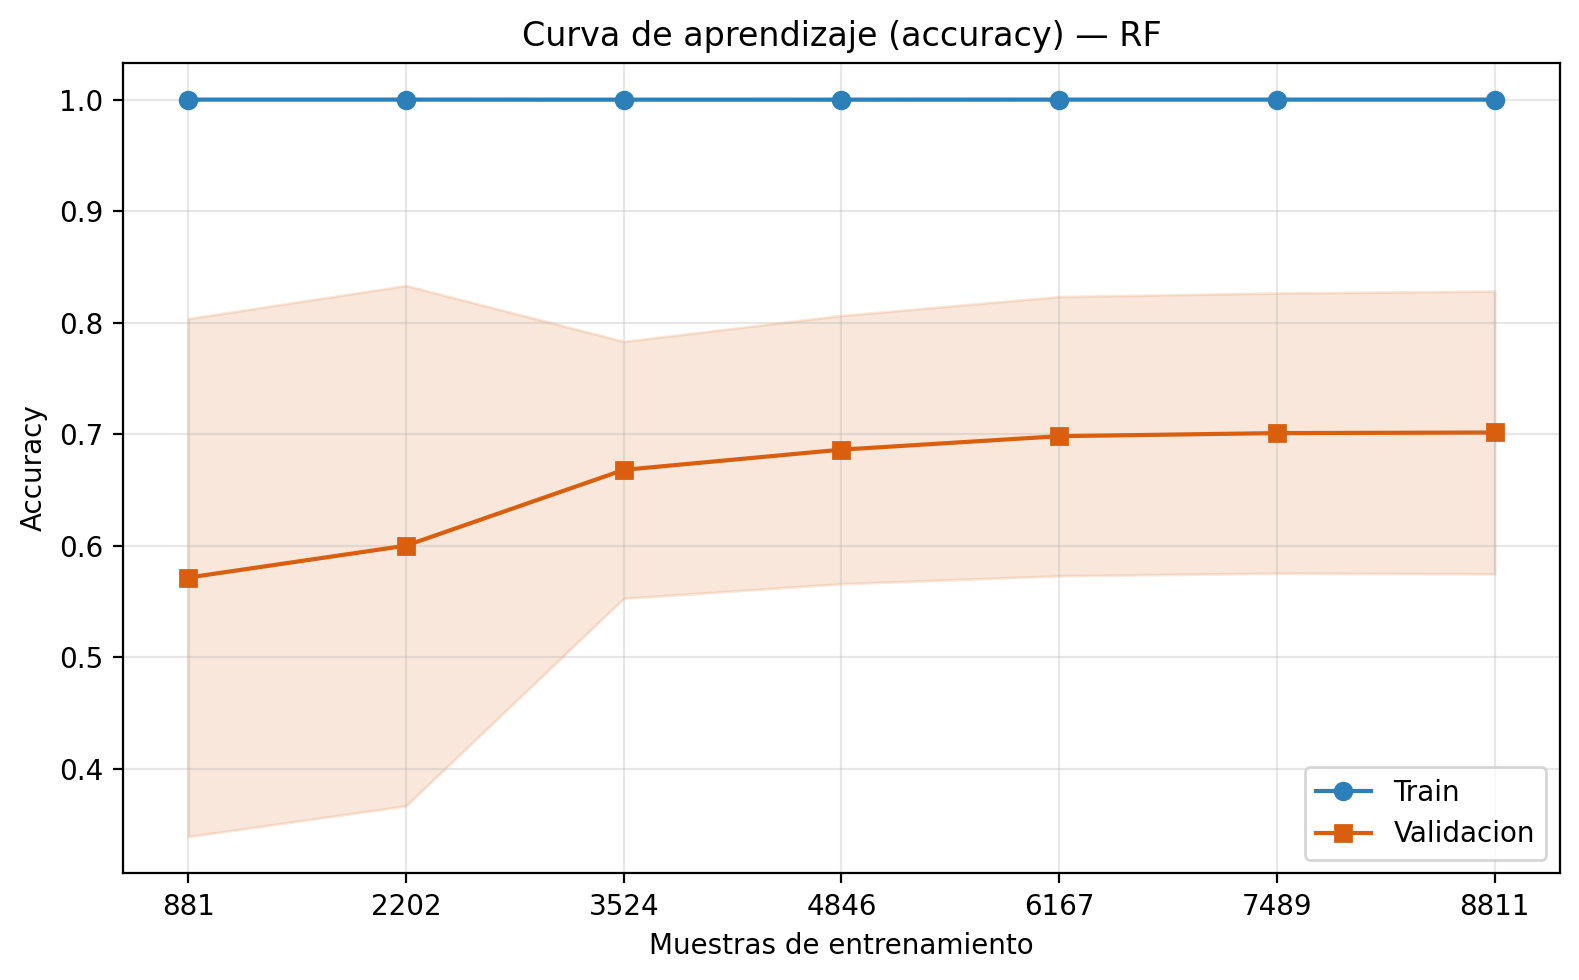

**Curva aprendizaje XGB** — `paper/figures/us-023-preview/04_baseline/learning_curve_xgb.png`:

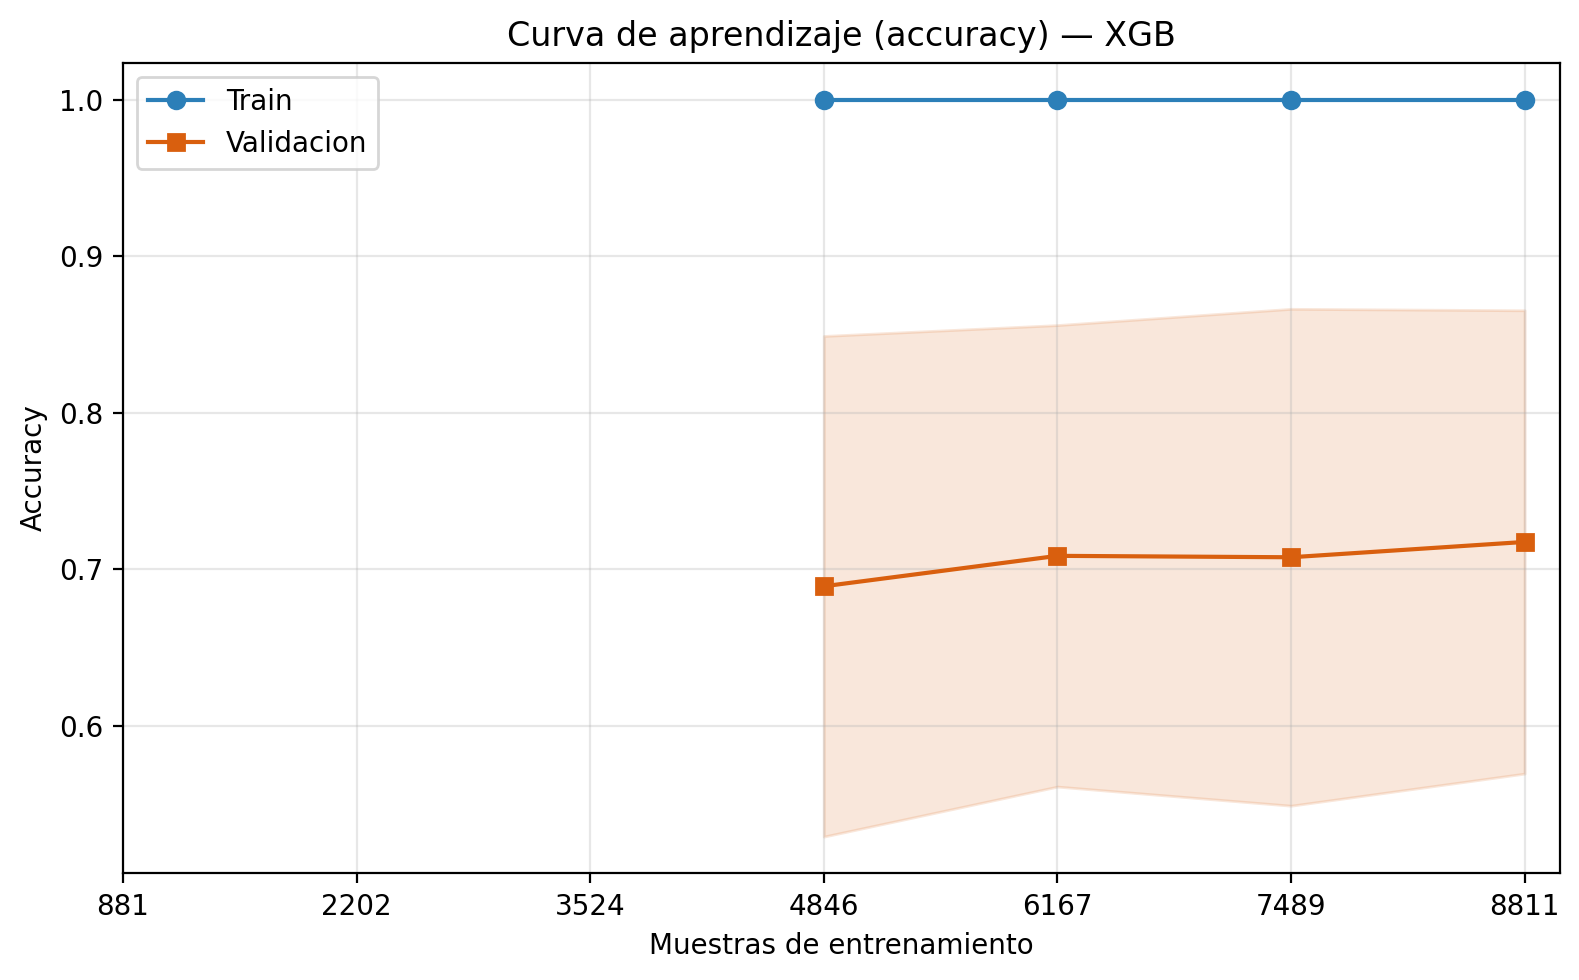

**Curva loss TempCNN** — `paper/figures/us-023-preview/05_reencuadre/loss_history_tempcnn.png`:

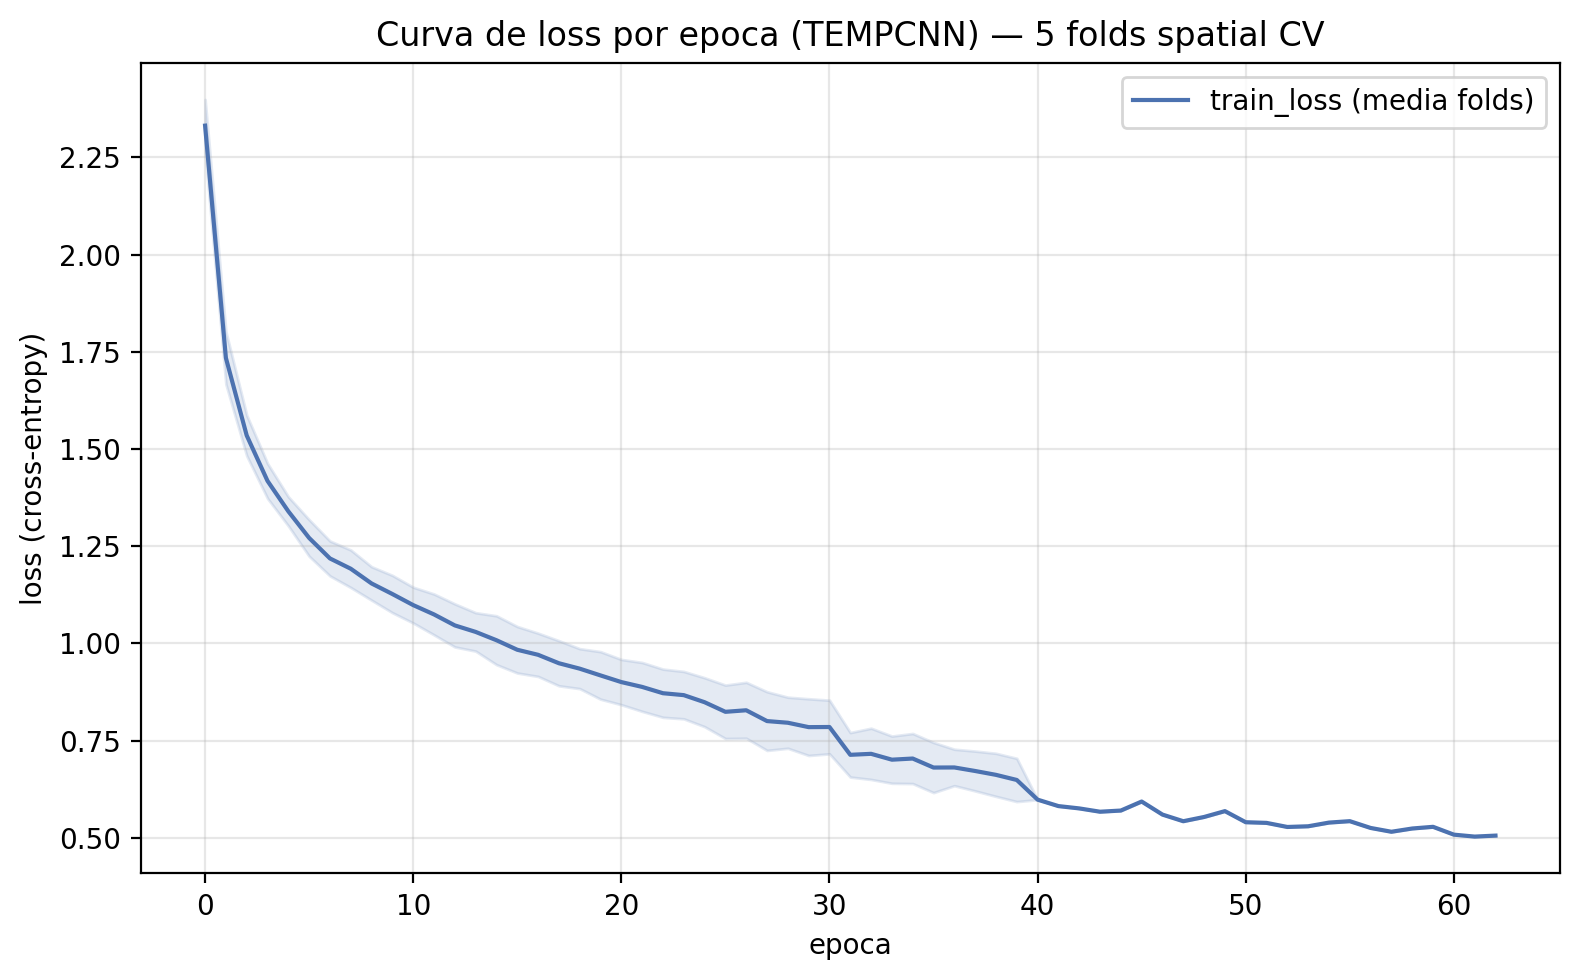

**Curva loss InceptionTime** — `paper/figures/us-023-preview/05_reencuadre/loss_history_inceptiontime.png`:

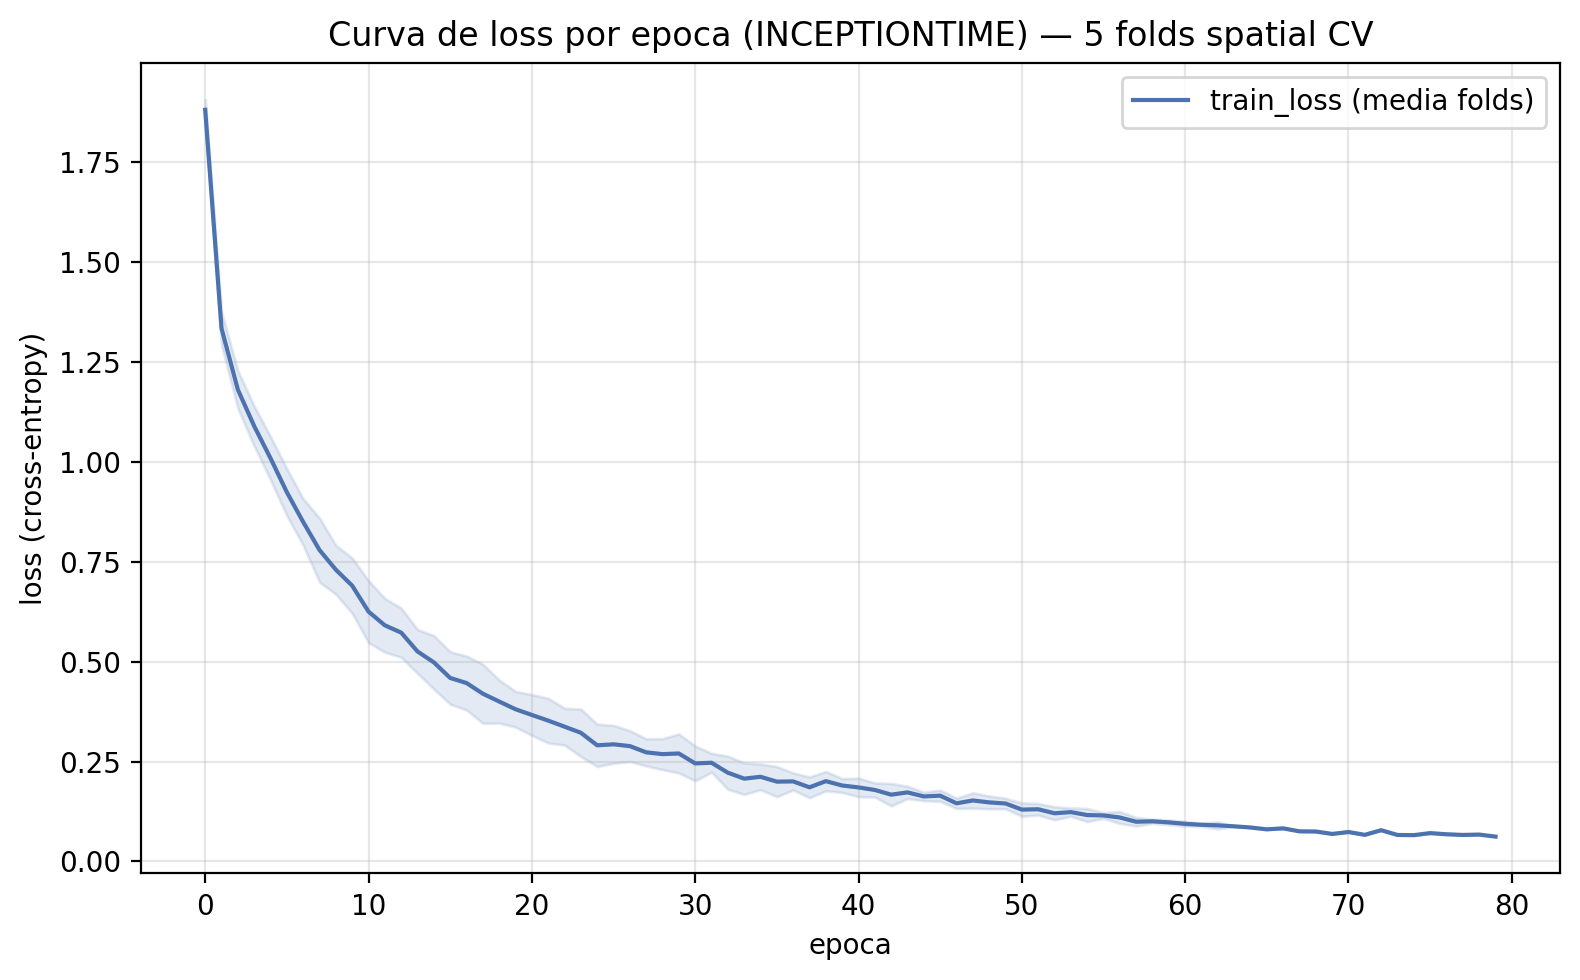

In [6]:
from IPython.display import Image

lc_figures = [
    ('Curva aprendizaje RF', 'paper/figures/us-023-preview/04_baseline/learning_curve_rf.png'),
    ('Curva aprendizaje XGB', 'paper/figures/us-023-preview/04_baseline/learning_curve_xgb.png'),
    ('Curva loss TempCNN', 'paper/figures/us-023-preview/05_reencuadre/loss_history_tempcnn.png'),
    ('Curva loss InceptionTime', 'paper/figures/us-023-preview/05_reencuadre/loss_history_inceptiontime.png'),
]
for label, rel_path in lc_figures:
    full_path = env.repo / rel_path
    if full_path.exists():
        display(Markdown(f'**{label}** — `{rel_path}`:'))
        display(Image(filename=str(full_path)))
    else:
        display(Markdown(f'> `{label}` no disponible (`{rel_path}` no existe).'))


## 5. P4 — ¿Cuál es la métrica adecuada?

**Respuesta: F1-macro.** Y nuestros propios números muestran por qué importa: XGBoost
tiene accuracy `0,75` y F1-weighted `0,71`, pero F1-macro **`0,43`**. Esa brecha es el
mensaje — la accuracy y la métrica ponderada se ven bien porque las clases mayoritarias
(pradera, trigo) se predicen bien, pero el promedio por clase castiga los cultivos
minoritarios donde el modelo falla. Reportar solo accuracy sería engañar al lector.

Justificación en lenguaje accesible:

- **Desbalance fuerte** (~31× entre el cultivo más y menos frecuente): un clasificador
  trivial que predice siempre la clase mayoritaria daría accuracy ≈ 25-30% pero F1-macro
  cercano a cero. Cualquier modelo serio tiene que superar eso con claridad.
- **Importan todas las clases por igual** (cada cultivo cuenta para quien lo siembra):
  F1-macro promedia el F1 por clase sin ponderar por soporte, así que penaliza los fallos
  en clases minoritarias. F1-weighted las disimula.
- **Kappa** mide acuerdo corregido por azar, pero no separa el comportamiento por clase —
  útil como medida global, insuficiente como única.
- **mIoU (Jaccard macro)** es equivalente a F1-macro en sensibilidad al desbalance, más
  estricto. Se reporta como segunda métrica.

**Decisión documentada**: principal F1-macro, secundaria mIoU; accuracy y kappa solo como
contexto.

## 6. P5 — Desempeño mínimo a obtener

**Target del proyecto**: F1-macro ≥ 0.60 sobre las 18 clases PASTIS con validación cruzada espacial. Justificación con tres referencias:

- **Punto de partida (random)**: clasificador aleatorio uniforme sobre 18 clases ≈ F1-macro 0.06; predicción trivial de la clase mayoritaria ≈ 0.03.
- **Estado del arte**: PASTIS-R con **U-TAE** (Garnot et al. 2021) reporta mIoU ~0.65; con DINOv3 + linear probe se alcanzan ~0.55-0.60.
- **Decisión del equipo**: F1-macro ≥ 0.60 sobre 18 clases con CV espacial es el mínimo publicable. Si no se alcanza con el baseline tabular del Avance 3 (lo más probable), hay dos rutas: agrupación fenológica (reduce a ~10 clases) o pasar a modelos densos (Avance 4) y ensambles (Avance 5).

In [7]:
if comparison_temporal is not None:
    best_row = comparison_temporal.row(0, named=True)
    best_f1 = float(best_row['f1_macro'])
    gap = F1_TARGET - best_f1
    status = '✓ cumplido' if gap <= 0 else f'✗ falta `{gap:+.4f}`'
    display(Markdown(
        f'**Estado actual del Avance 3**: el mejor modelo es '
        f'`{best_row["model"]}` con F1-macro = `{best_f1:.4f}`. '
        f'Target = `{F1_TARGET}` → {status}.'
    ))
    if gap > 0:
        display(Markdown(
            '**Plan para cerrar el gap**:\n\n'
            '1. Agrupación fenológica de clases minoritarias en `other_minor`.\n'
            '2. Modelos densos del Avance 4 (U-Net, U-TAE, TSViT, Swin-UNETR).\n'
            '3. Ensambles del Avance 5 (voting, bagging, stacking, blending) + Gemma 4 LoRA.'
        ))


**Estado actual del Avance 3**: el mejor modelo es `xgb` con F1-macro = `0.4332`. Target = `0.6` → ✗ falta `+0.1668`.

**Plan para cerrar el gap**:

1. Agrupación fenológica de clases minoritarias en `other_minor`.
2. Modelos densos del Avance 4 (U-Net, U-TAE, TSViT, Swin-UNETR).
3. Ensambles del Avance 5 (voting, bagging, stacking, blending) + Gemma 4 LoRA.

## 7. ¿Cuánto vale el embedding fundacional? AlphaEarth vs Sentinel-2 crudo vs combinado

Esta es la comparación que justifica usar AlphaEarth. El `04_baseline` entrena
**3 modelos × 3 escenarios = 9 combinaciones** sobre exactamente las mismas parcelas
(inner join), variando solo qué características entran:

- **Sentinel-2 crudo** (10 bandas): el reflejo espectral directo, sin procesar.
- **AlphaEarth** (64 dims): el embedding fundacional preentrenado de Google.
- **Vector combinado** (185 features): AlphaEarth + índices espectrales + estadísticas
  temporales + FFT.

**El resultado, con XGBoost** (la fila más alta de cada escenario): Sentinel-2 crudo
`0,26` → AlphaEarth `0,35` → combinado `0,41`. **AlphaEarth solo casi duplica a las
bandas crudas** (+0,09 F1-macro con las mismas parcelas), y el vector combinado le suma
otro +0,06. Es decir: el embedding fundacional aporta más que toda la ingeniería de
características manual, y ambos son complementarios. Esto valida la decisión irrevocable
del proyecto de construir sobre AlphaEarth en vez de entrenar un foundation model propio.

La tabla y el gráfico de barras debajo (de `04_baseline` §11).

**Comparativa de escenarios (9 filas)**:

scenario,model,n_features,f1_macro,f1_weighted,miou,train_time_s
str,str,i64,f64,f64,f64,f64
"""Vector combinado (187 feat)""","""XGB""",185,0.4098,0.692,0.3121,308.219
"""Vector combinado (187 feat)""","""LGBM""",185,0.3901,0.6834,0.299,925.48
"""Vector combinado (187 feat)""","""RF""",185,0.3646,0.6571,0.2695,209.683
"""AlphaEarth 64-dim""","""XGB""",64,0.3547,0.6545,0.2595,163.118
"""AlphaEarth 64-dim""","""LGBM""",64,0.3391,0.6443,0.2506,378.717
"""AlphaEarth 64-dim""","""RF""",64,0.3221,0.6306,0.2316,135.916
"""Sentinel-2 crudo (10 bandas)""","""XGB""",10,0.257,0.5634,0.1765,94.531
"""Sentinel-2 crudo (10 bandas)""","""LGBM""",10,0.2561,0.5668,0.1776,131.303
"""Sentinel-2 crudo (10 bandas)""","""RF""",10,0.2044,0.4948,0.135,52.046


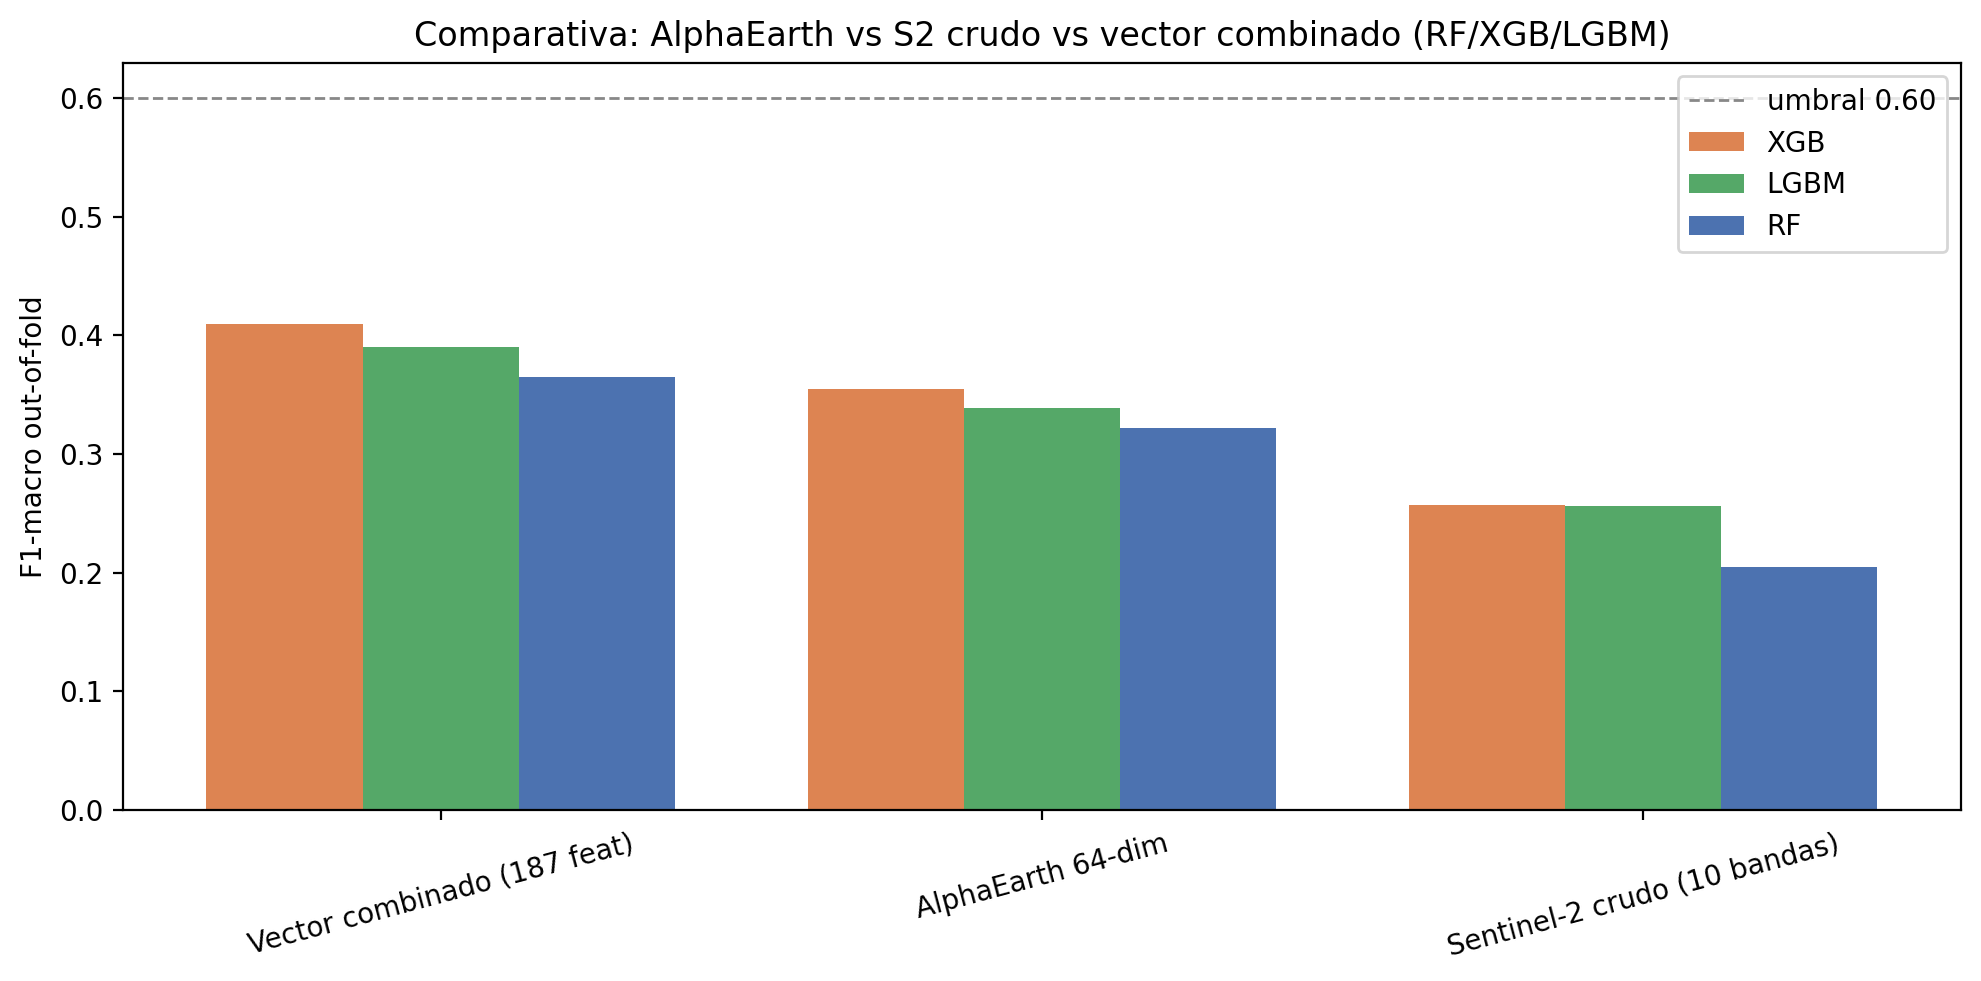

In [8]:
scenarios_path = Path(COMPARISON_SCENARIOS_PATH)
if scenarios_path.exists():
    scenarios = pl.read_csv(scenarios_path)
    display(Markdown('**Comparativa de escenarios (9 filas)**:'))
    display(scenarios)
fig_path = env.repo / 'paper/figures/us-023-preview/04_baseline/comparison_barplot.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    display(Markdown('> Figura comparativa no disponible.'))


## 8. ¿Aporta un extractor visual especializado? FarSLIP vs AlphaEarth

El `04_farslip_eval_pastis` evalúa si **FarSLIP** (un CLIP especializado en teledetección,
Li et al. 2025) aporta señal de cultivo por encima de AlphaEarth, y de paso si su segunda
etapa de entrenamiento (alineamiento región-categoría) sirve. Mide la separabilidad de
los embeddings con un clasificador lineal (LogReg, 5-fold) sobre las mismas parcelas, en
régimen balanceado y completo.

**El resultado es contundente y va en contra de FarSLIP**:

| Espacio | F1-macro (balanceado) | dims |
|---------|----------------------|------|
| AlphaEarth 2018+2019 | `0,233` | 128 |
| AlphaEarth 2019 | `0,224` | 64 |
| FarSLIP-s2 | `0,163` | 512 |
| FarSLIP-s1 | `0,162` | 512 |

- **AlphaEarth gana por amplio margen** (`0,22-0,23` vs `0,16`) y con 4-8× menos
  dimensiones. Es esperable: AlphaEarth consume series multi-temporales y multi-banda,
  mientras FarSLIP solo ve una imagen RGB promediada en el tiempo, que descarta el
  calendario de crecimiento.
- **La segunda etapa de FarSLIP no aporta** (s1 `0,162` ≈ s2 `0,163`): el alineamiento
  región-categoría que ayuda en detección de objetos no se traslada a cultivos.
- **La vista multi-año de AlphaEarth sí aporta** (`0,233` vs `0,224`, +0,009): una pista
  útil de cara al ensamble del Avance 5.

**Decisión**: FarSLIP queda descartado como bloque del baseline y como clasificador de
cultivos; el embedding base es **AlphaEarth multi-temporal**. Debajo, el gráfico de barras
por espacio y los planos UMAP que lo confirman visualmente.

**Separabilidad por espacio de embedding** (F1-macro, mayor = mejor):

espacio,regimen,f1_macro,f1_std,silhouette,n,dims
str,str,f64,f64,f64,i64,i64
"""AlphaEarth-2018+2019""","""balanceado""",0.2325,0.0145,-0.0804,5449,128
"""AlphaEarth-2019""","""balanceado""",0.2239,0.019,-0.0861,5449,64
"""FarSLIP-s2""","""balanceado""",0.1631,0.0133,-0.0449,5449,512
"""FarSLIP-s1""","""balanceado""",0.162,0.0117,-0.0427,5449,512
"""AlphaEarth-2018+2019""","""completo""",0.174,0.0025,-0.0936,50495,128
"""AlphaEarth-2019""","""completo""",0.1632,0.0026,-0.0969,50495,64
"""FarSLIP-s1""","""completo""",0.1339,0.0013,-0.0294,50495,512
"""FarSLIP-s2""","""completo""",0.1334,0.0013,-0.0313,50495,512


**F1-macro por espacio (barras)** — `paper/figures/us-023-preview/04_farslip_eval_pastis/f1_macro_by_space.png`:

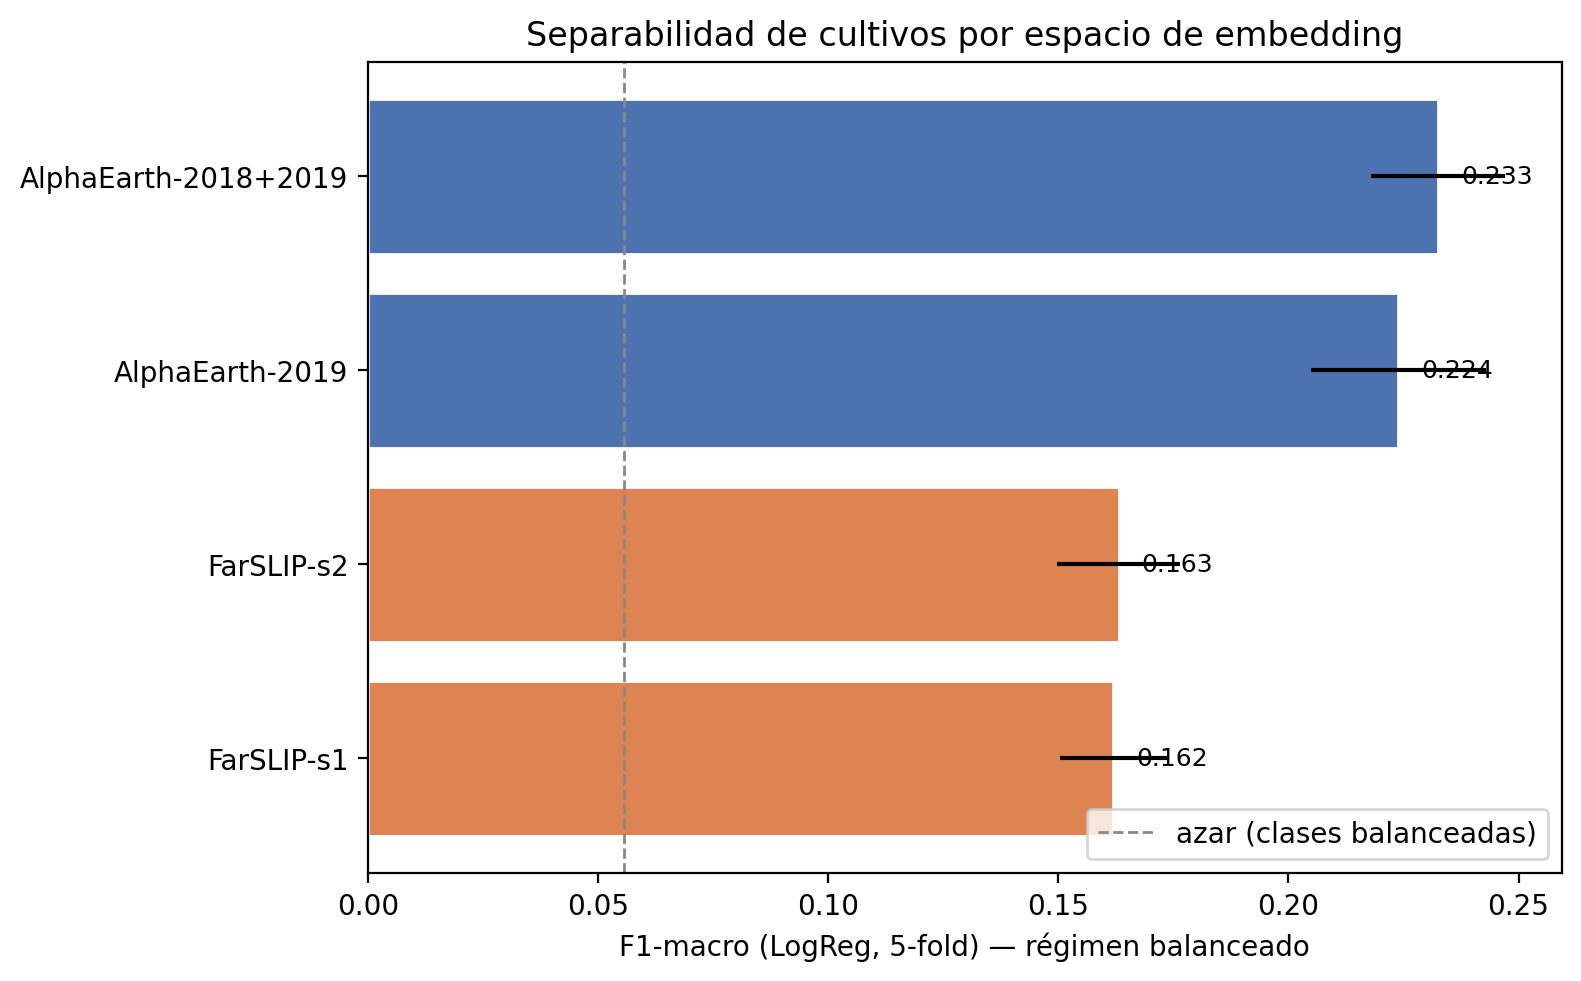

**UMAP AlphaEarth-2019 por clase** — `paper/figures/us-023-preview/04_farslip_eval_pastis/umap_alphaearth_2019_by_class.png`:

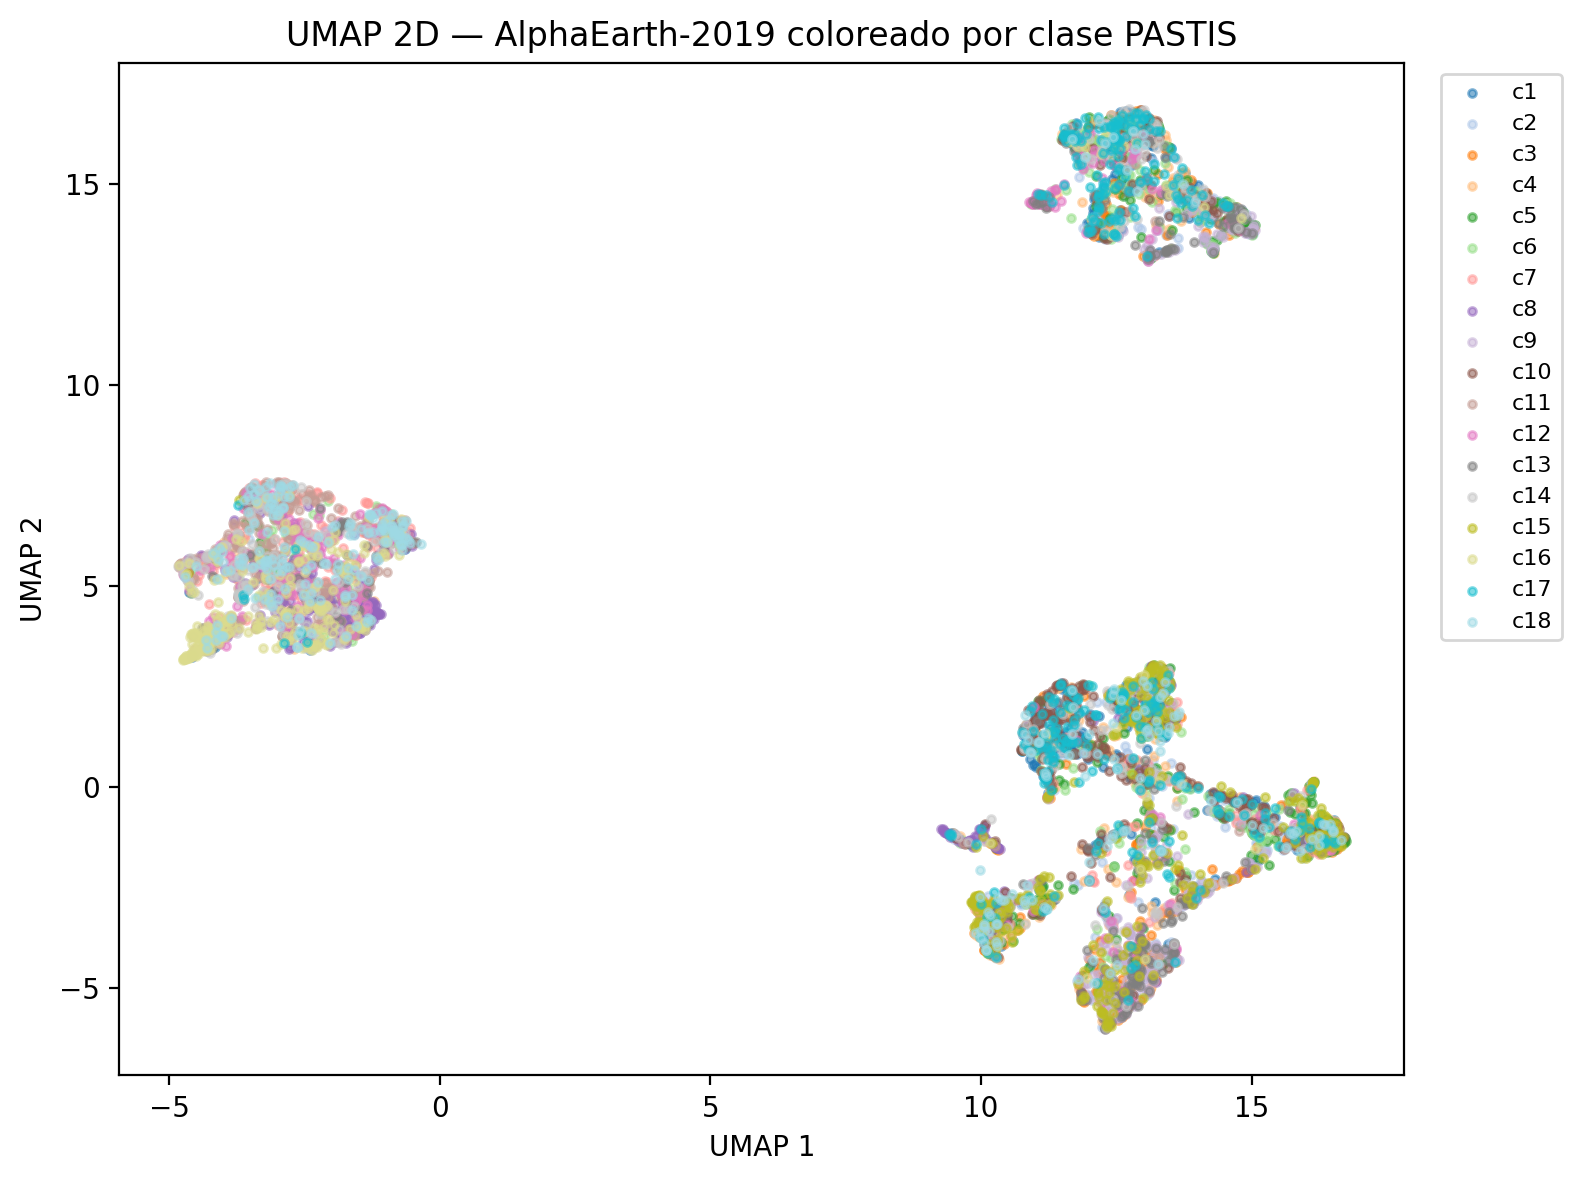

**UMAP FarSLIP-s2 por clase** — `paper/figures/us-023-preview/04_farslip_eval_pastis/umap_farslip_s2_by_class.png`:

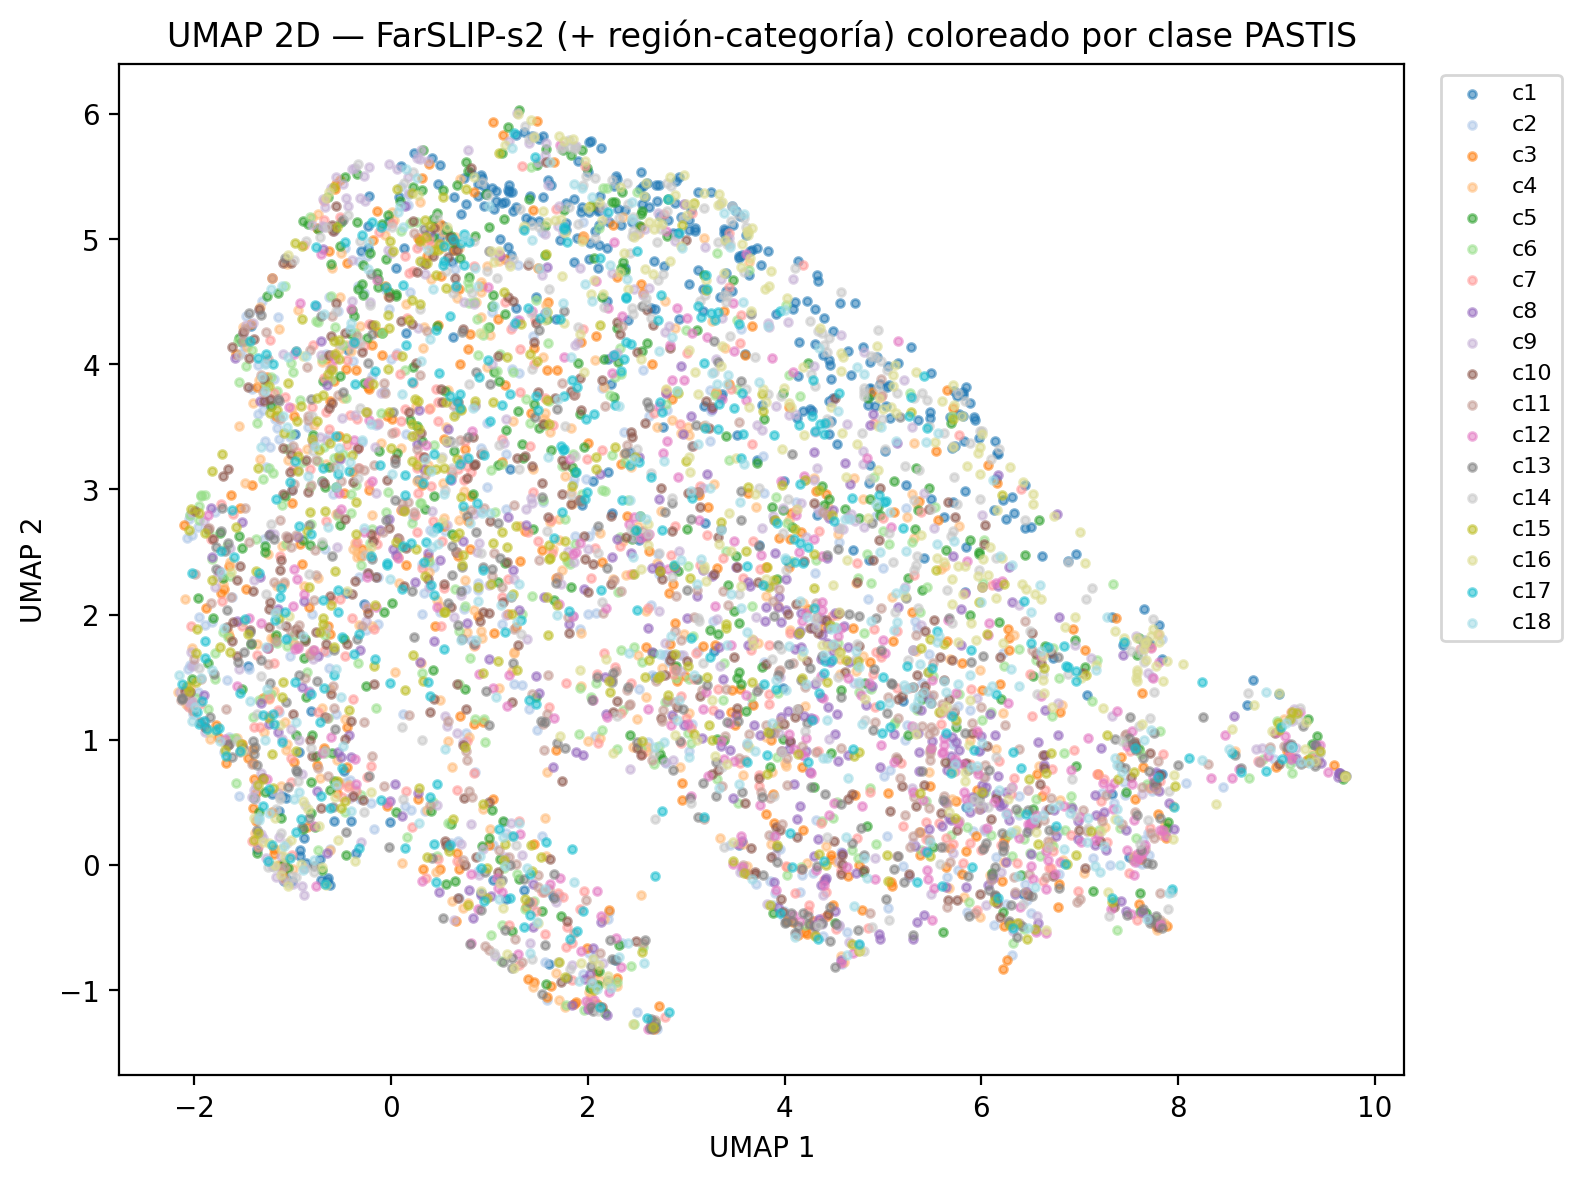

In [9]:
# Read the real separability table (FarSLIP s1/s2 vs AlphaEarth 2019/2018+2019).
SEPARABILITY_PATH = "reports/baseline/04_farslip_eval_pastis/separability_comparison.parquet"
separability = _read_or_skip(SEPARABILITY_PATH, "separability_comparison (04_farslip)")
if separability is not None:
    display(Markdown("**Separabilidad por espacio de embedding** (F1-macro, mayor = mejor):"))
    display(separability.sort(["regimen", "f1_macro"], descending=[False, True]))

# Figures from the FarSLIP-vs-AlphaEarth comparison.
farslip_figures = [
    ("F1-macro por espacio (barras)",
     "paper/figures/us-023-preview/04_farslip_eval_pastis/f1_macro_by_space.png"),
    ("UMAP AlphaEarth-2019 por clase",
     "paper/figures/us-023-preview/04_farslip_eval_pastis/umap_alphaearth_2019_by_class.png"),
    ("UMAP FarSLIP-s2 por clase",
     "paper/figures/us-023-preview/04_farslip_eval_pastis/umap_farslip_s2_by_class.png"),
]
for label, rel_path in farslip_figures:
    full_path = env.repo / rel_path
    if full_path.exists():
        display(Markdown(f"**{label}** — `{rel_path}`:"))
        display(Image(filename=str(full_path)))
    else:
        display(Markdown(f"> `{label}` no disponible (`{rel_path}`)."))

## 9. ¿Hay estructura de cultivo sin mirar dónde está la parcela?

Una prueba conceptual importante: si agrupamos las parcelas usando **solo la firma
fenológica** (la forma de la curva NDVI a lo largo del año: cuándo crece, cuándo madura),
**sin coordenadas ni región**, ¿emergen grupos que correspondan a cultivos reales?

El `05_reencuadre` §6 corre KMeans sobre la firma fenológica pura y proyecta el resultado
a UMAP. La respuesta es **sí**: los clusters corresponden a arquetipos estacionales
reconocibles — cultivos de invierno (pico temprano, senescencia temprana), cultivos de
verano largos (pico tardío, maduración larga), y ciclos cortos. Las curvas NDVI medias
por cluster son distintas y agronómicamente interpretables.

Esto refuerza el hallazgo de P2: el modelo aprende **fenología, no geografía**. La señal
de cultivo está en la dinámica temporal, lo que explica por qué los modelos que la leen
bien (los densos del Avance 4) acabarán ganando. Debajo, el plano UMAP coloreado por
cluster y las curvas NDVI medias por grupo.

**UMAP firma fenológica + KMeans** — `paper/figures/us-023-preview/05_reencuadre/umap_clusters.png`:

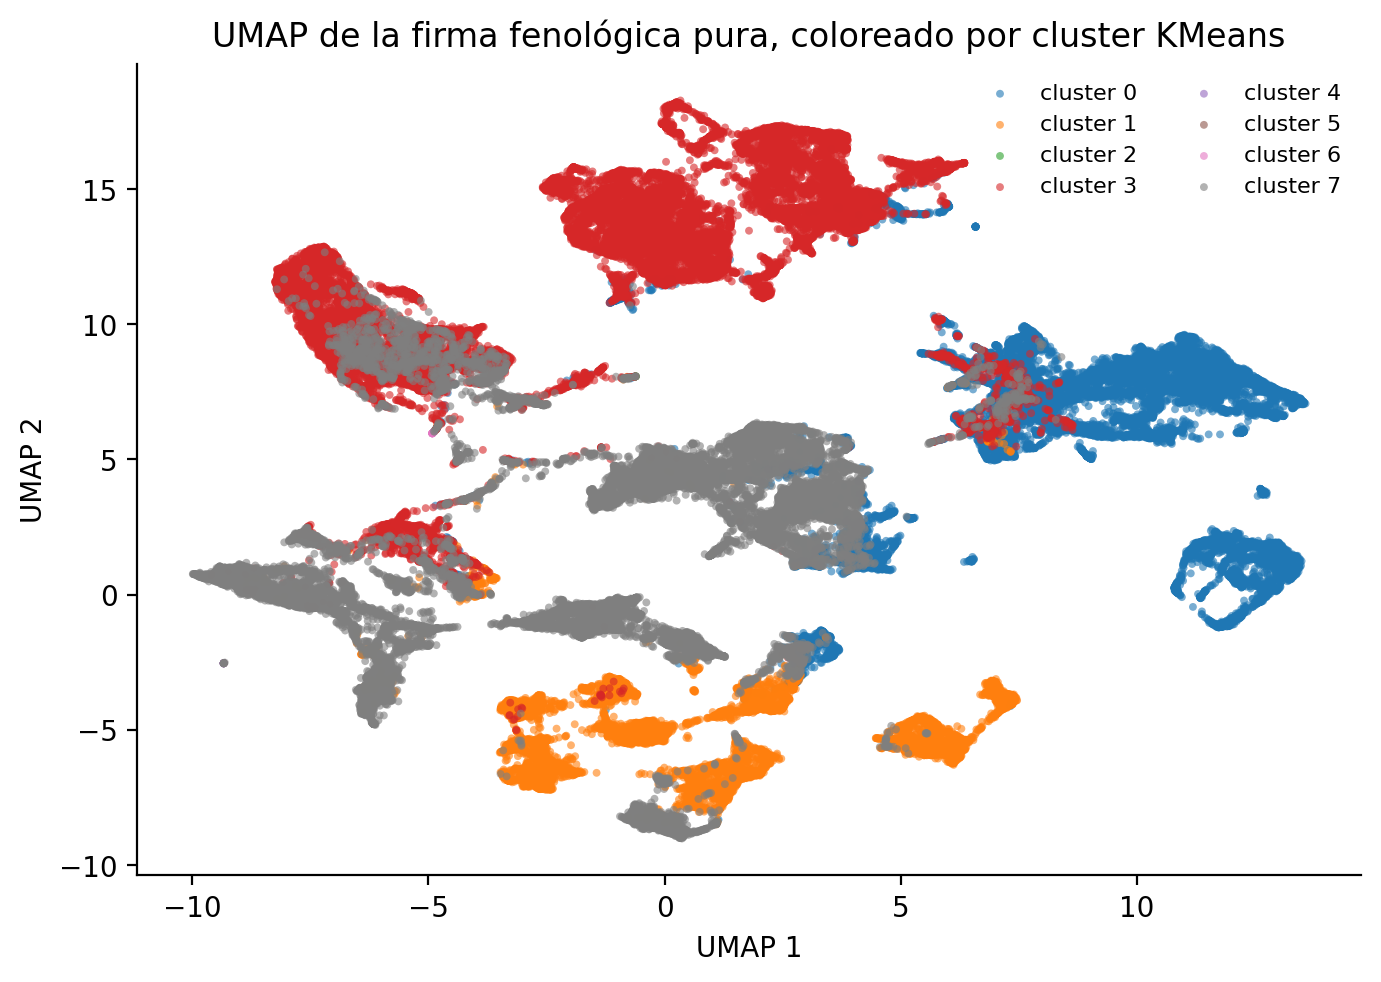

**Curvas NDVI medias por cluster** — `paper/figures/us-023-preview/05_reencuadre/cluster_ndvi_curves.png`:

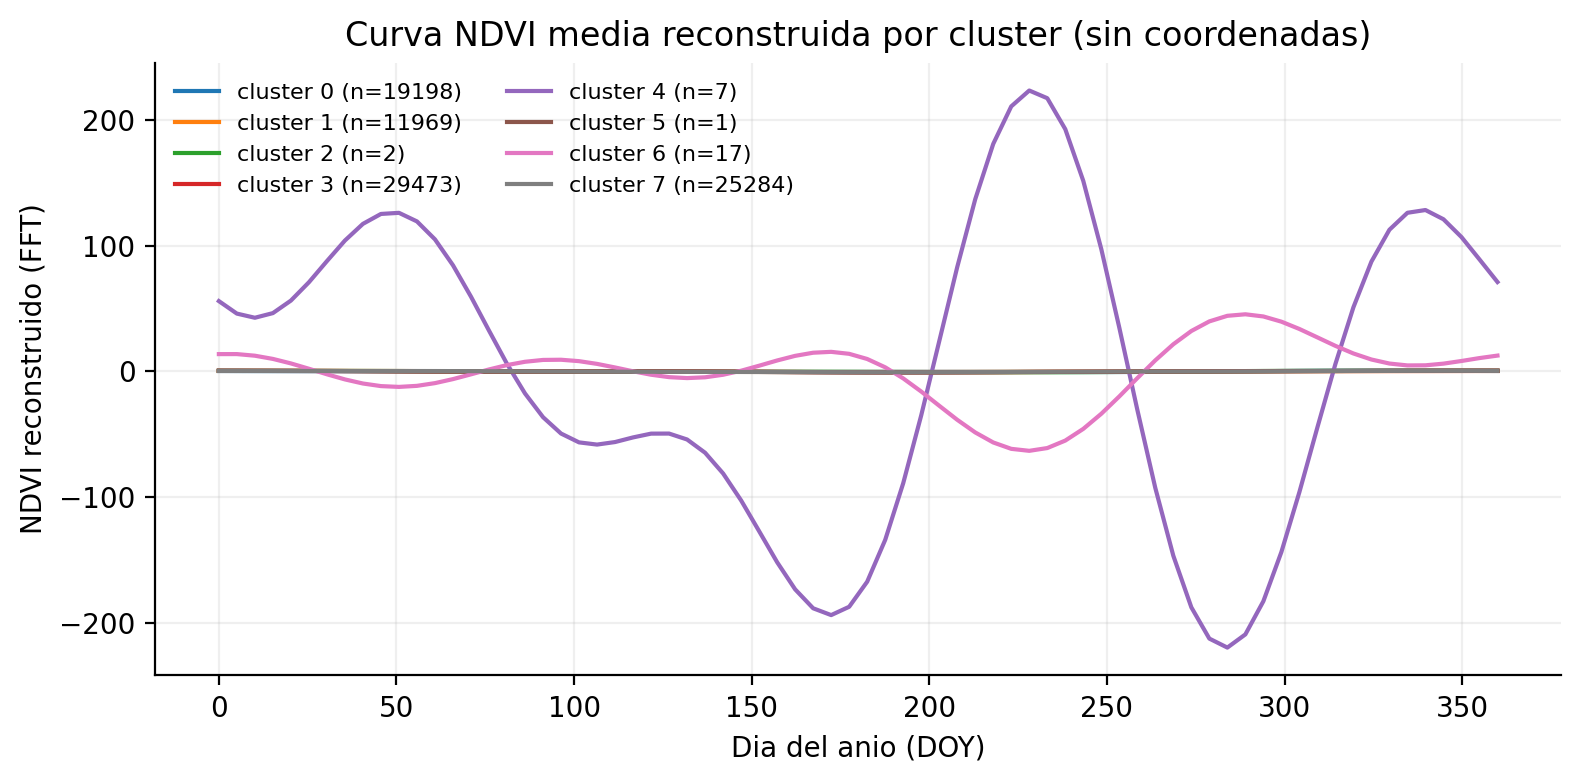

In [10]:
cluster_figures = [
    ('UMAP firma fenológica + KMeans',
     'paper/figures/us-023-preview/05_reencuadre/umap_clusters.png'),
    ('Curvas NDVI medias por cluster',
     'paper/figures/us-023-preview/05_reencuadre/cluster_ndvi_curves.png'),
]
for label, rel_path in cluster_figures:
    full_path = env.repo / rel_path
    if full_path.exists():
        display(Markdown(f'**{label}** — `{rel_path}`:'))
        display(Image(filename=str(full_path)))
    else:
        display(Markdown(f'> `{label}` no disponible.'))


## 10. Cuatro hipótesis del Avance 3 con decisiones consolidadas

Cada hipótesis se cierra con una decisión cuantitativa apoyada en la ablación. Las cifras son leídas del `ablation_table.parquet` que produjo `05_reencuadre`.

In [11]:
import math

def _delta_or_none(name: str) -> float | None:
    if ablation_optional is None:
        return None
    rows = ablation_optional.filter(pl.col('feature_set') == name)
    if rows.height == 0:
        return None
    val = rows.get_column('delta_vs_full').to_list()[0]
    return float(val) if val is not None and not (isinstance(val, float) and math.isnan(val)) else None

def _decision(delta: float | None, threshold: float = PROMOTE_THRESHOLD) -> str:
    if delta is None:
        return 'pendiente (sin datos)'
    if delta >= threshold:
        return f'promover (delta = {delta:+.4f} >= +{threshold:.3f})'
    if delta <= -threshold:
        return f'descartar (delta = {delta:+.4f} <= -{threshold:.3f})'
    return f'diferir a stacking (delta = {delta:+.4f} en zona neutra)'

# H-1 geom leakage: from the BASE ablation (04c). 'no_geom' delta vs 'full' = 0.0
# means dropping geometry costs nothing -> it was leakage, decision = discard.
h1_decision = 'descartar (decision cualitativa)'
if ablation_base is not None:
    ng = ablation_base.filter(pl.col('feature_set') == 'no_geom')
    if ng.height:
        d = ng.get_column('delta_vs_full').to_list()[0]
        if d is not None and not (isinstance(d, float) and math.isnan(d)):
            h1_decision = (
                f'descartar - quitar geom_* cuesta delta = {float(d):+.4f} (es fuga, no senal)'
            )

# H-2 FarSLIP: from the separability comparison (04_farslip). FarSLIP loses to
# AlphaEarth, so it is discarded as a block.
h2_decision = 'descartar (decision cualitativa)'
if 'separability' in dir() and separability is not None:
    bal = separability.filter(pl.col('regimen') == 'balanceado')
    far = bal.filter(pl.col('espacio').str.starts_with('FarSLIP'))['f1_macro'].max()
    ae = bal.filter(pl.col('espacio').str.starts_with('AlphaEarth'))['f1_macro'].max()
    if far is not None and ae is not None:
        h2_decision = (
            f'descartar - FarSLIP F1-macro = {float(far):.4f} < AlphaEarth {float(ae):.4f}'
        )

hypotheses = pl.DataFrame({
    'hipotesis': ['H-1 geom leakage', 'H-2 FarSLIP', 'H-3 pheno_text Gemini', 'H-4 firma espectral REP'],
    'descripcion': [
        'columnas geom_* son proxy de region (leakage espacial)',
        'FarSLIP aporta senal complementaria al embedding tabular',
        'descripcion fenologica textual con LLM aporta senal semantica',
        'Red Edge Position (Frampton 2013) captura forma espectral por epoca',
    ],
    'decision': [
        h1_decision,
        h2_decision,
        _decision(_delta_or_none('with_pheno_text')),
        _decision(_delta_or_none('with_spectral_signature')),
    ],
})
display(Markdown('**Tabla H-1..H-4 - decisiones consolidadas**:'))
display(hypotheses)
hypotheses.write_parquet(env.reports_dir / 'decision_table.parquet')

**Tabla H-1..H-4 - decisiones consolidadas**:

hipotesis,descripcion,decision
str,str,str
"""H-1 geom leakage""","""columnas geom_* son proxy de region (leakage espacial)""","""descartar - quitar geom_* cuesta delta = +0.0000 (es fuga, n…"
"""H-2 FarSLIP""","""FarSLIP aporta senal complementaria al embedding tabular""","""descartar - FarSLIP F1-macro = 0.1631 < AlphaEarth 0.2325"""
"""H-3 pheno_text Gemini""","""descripcion fenologica textual con LLM aporta senal semantic…","""descartar (delta = -0.1453 <= -0.005)"""
"""H-4 firma espectral REP""","""Red Edge Position (Frampton 2013) captura forma espectral po…","""descartar (delta = -0.1477 <= -0.005)"""


## 11. Conjunto ganador con `select_winning_features`

Esta es la **única llamada a `select_winning_features` en todo el proyecto**. Recibe la `ablation_table` de `05_reencuadre`, promueve bloques con `delta >= +0.005`, descarta `geom_*` siempre, y persiste:

- `data/features/features_fused_winning_pastis.parquet` — dataset filtrado a las columnas ganadoras.
- `data/features/features_fused_winning_pastis.manifest.json` — lista nominal exacta de columnas (para que los modelos densos del Avance 4 y los ensambles del Avance 5 lean exactamente las mismas).

In [12]:
from ml.features.winning_features import (
    select_winning_features,
    persist_winning_features,
)

if ablation_optional is None:
    raise FileNotFoundError(
        f'No se puede llamar a select_winning_features sin la tabla `{ABLATION_OPTIONAL_PATH_05}`. '
        'Ejecuta `05_reencuadre_fenologico.ipynb` antes de Avance3.'
    )

fused_path = Path(FUSED_PATH)
if not fused_path.exists():
    raise FileNotFoundError(
        f'No existe `{fused_path}`. Ejecuta `05_reencuadre_fenologico.ipynb` '
        '(genera el fused completo durante la materialización).'
    )
fused = pl.read_parquet(fused_path)

winning = select_winning_features(
    ablation_optional,
    available_cols=fused.columns,
    promote_threshold=PROMOTE_THRESHOLD,
    discard_geom=True,
)
display(Markdown('**Decisiones por bloque** (única fuente de verdad):'))
display(pl.DataFrame({
    'bloque': list(winning.decisions.keys()),
    'promovido': list(winning.decisions.values()),
}))
display(Markdown(
    f'**Conjunto ganador**: `{winning.name}` con `{len(winning.feature_cols)}` columnas.'
))
display(Markdown('### Rationale'))
display(Markdown(winning.rationale))

winning_path = persist_winning_features(
    winning, fused,
    output_path=WINNING_OUTPUT, overwrite=True,
)
# persist_winning_features returns a relative Path; we resolve it
# against env.repo only to display it (relative_to requires the same type).
_winning_abs = winning_path if winning_path.is_absolute() else env.repo / winning_path
_winning_rel = _winning_abs.relative_to(env.repo)
display(Markdown(
    f'**Conjunto ganador guardado**: `{_winning_rel}` · '
    f'**Manifest**: `{_winning_rel.with_suffix(".manifest.json")}`'
))

import json
manifest = json.loads(
    Path(WINNING_OUTPUT).with_suffix('.manifest.json').read_text(encoding='utf-8')
)
display(Markdown(f'**Número de características**: `{manifest["n_features"]}`'))
display(Markdown('**Características ganadoras** (primeras 40):'))
display(pl.Series('feature', manifest['feature_cols'][:40]).to_frame())


2026-06-04 14:02:33 [info     ] winning_features_selected      decisions={'geom': False, 'farslip': False, 'pheno_text': False, 'spectral_signature': False} n_cols=96 name=phenology+ae+indices


**Decisiones por bloque** (única fuente de verdad):

bloque,promovido
str,bool
"""geom""",false
"""farslip""",false
"""pheno_text""",false
"""spectral_signature""",false


**Conjunto ganador**: `phenology+ae+indices` con `96` columnas.

### Rationale

...

2026-06-04 14:02:33 [info     ] winning_features_persisted     manifest=data\features\features_fused_winning_pastis.manifest.json n_features=96 parquet=data\features\features_fused_winning_pastis.parquet


**Conjunto ganador guardado**: `data\features\features_fused_winning_pastis.parquet` · **Manifest**: `data\features\features_fused_winning_pastis.manifest.json`

**Número de características**: `96`

**Características ganadoras** (primeras 40):

feature
str
"""EVI_fft_amp_0"""
"""EVI_fft_amp_1"""
"""EVI_fft_amp_2"""
"""EVI_fft_amp_3"""
"""EVI_fft_phase_0"""
"""EVI_fft_phase_1"""
"""EVI_fft_phase_2"""
"""EVI_fft_phase_3"""
"""NDVI_fft_amp_0"""


## 12. Trazabilidad MLflow consolidada

Cada notebook abre runs MLflow propios con tags `code_version` (SHA git) y `data_version` (hash DVC). Aquí listamos los experimentos para que cualquier auditor reabra y reproduzca.

In [13]:
from ml.utils.mlflow_utils import resolve_tracking_uri, server_is_reachable
import mlflow
from mlflow.tracking import MlflowClient

# Same defensive logic as the MLflow setup cells: if the server
# does not respond, fall back to `file:./mlruns` and query the local runs.
_candidate_uri = resolve_tracking_uri(None, probe_server=False)
if _candidate_uri.startswith(('http://', 'https://')) and not server_is_reachable(_candidate_uri):
    mlflow_uri = 'file:./mlruns'
    display(Markdown(
        f'> Servidor MLflow `{_candidate_uri}` no responde. '
        'Consulto runs locales en `file:./mlruns`.'
    ))
else:
    mlflow_uri = _candidate_uri
mlflow.set_tracking_uri(mlflow_uri)
client = MlflowClient(tracking_uri=mlflow_uri)

experiments_av3 = [
    'baseline-04-tabular',
    'baseline-04b-pilot',
    'baseline-04c-ablation',
    'baseline-04-farslip-s1-vs-s2',
    'baseline-05-reencuadre',
]
summary_rows = []
for exp_name in experiments_av3:
    exp = client.get_experiment_by_name(exp_name)
    if exp is None:
        summary_rows.append({
            'experimento': exp_name, 'n_runs': 0,
            'experiment_id': 'n/a', 'tracking_uri': mlflow_uri,
        })
        continue
    runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=200)
    summary_rows.append({
        'experimento': exp_name,
        'n_runs': len(runs),
        'experiment_id': exp.experiment_id,
        'tracking_uri': mlflow_uri,
    })
mlflow_summary = pl.DataFrame(summary_rows)
display(Markdown('**Resumen de experimentos MLflow del Avance 3**:'))
display(mlflow_summary)
mlflow_summary.write_parquet(env.reports_dir / 'mlflow_summary.parquet')

**Resumen de experimentos MLflow del Avance 3**:

experimento,n_runs,experiment_id,tracking_uri
str,i64,str,str
"""baseline-04-tabular""",9,"""3""","""http://localhost:5010"""
"""baseline-04b-pilot""",10,"""2""","""http://localhost:5010"""
"""baseline-04c-ablation""",5,"""4""","""http://localhost:5010"""
"""baseline-04-farslip-s1-vs-s2""",20,"""8""","""http://localhost:5010"""
"""baseline-05-reencuadre""",39,"""6""","""http://localhost:5010"""


## 13. Referencias

- **Brown et al. (2025)** — *AlphaEarth Foundations: a Global Foundation Model for Earth*. Embedding satelital 64-dim.
- **Pelletier, Webb & Petitjean (2019)** — *TempCNN: Temporal Convolutional Neural Network for Satellite Image Time Series Classification*. DOI 10.3390/rs11050523.
- **Fawaz et al. (2020)** — *InceptionTime: Finding AlexNet for Time Series Classification*. DOI 10.1007/s10618-020-00710-y.
- **Garnot et al. (2021)** — *Panoptic Segmentation of Satellite Image Time Series with Convolutional Temporal Attention Networks (U-TAE)*. ICCV 2021.
- **Frampton et al. (2013)** — *Evaluating the capabilities of Sentinel-2 for quantitative estimation of biophysical variables in vegetation (Red Edge Position)*. DOI 10.1016/j.isprsjprs.2013.04.007.
- **Wen et al. (2025)** — *Phenology Description is All You Need!*. Descripción fenológica textual + LLM.
- **Li et al. (2025)** — *FarSLIP: Fine-grained Aligned Remote Sensing Language-Image Pre-training*. arXiv:2511.14901. Pesos: HuggingFace `ZhenShiL/FarSLIP`.
- **Lundberg & Lee (2017)** — *A Unified Approach to Interpreting Model Predictions (SHAP)*. NeurIPS.

**Atribuciones de licencia**: ver [`docs/licenses/DATA_LICENSE.md`](../../docs/licenses/DATA_LICENSE.md).

---

## Cierre del Avance 3

**Las cinco preguntas, respondidas con cifras**:

- **P1 (baseline)**: XGBoost, F1-macro `0,43` — el mejor de cinco modelos.
- **P2 (importancia)**: AlphaEarth domina; geometría es fuga (delta `0,0`); texto-LLM y
  REP restan; FarSLIP pierde contra AlphaEarth.
- **P3 (ajuste)**: tabulares con sobreajuste leve controlado; temporales-FFT subajustan.
- **P4 (métrica)**: F1-macro (la brecha accuracy `0,75` vs F1-macro `0,43` lo justifica).
- **P5 (mínimo)**: target `0,60`; estado `0,43`; se cierra con densos + ensambles.

**Lo que entregamos**:

- 5 modelos reentrenados sobre el conjunto ganador, con trazabilidad MLflow completa.
- La comparación FarSLIP vs AlphaEarth resuelta: **AlphaEarth multi-temporal es el
  embedding base** (FarSLIP descartado).
- Conjunto de características ganador persistido en `features_fused_winning_pastis.parquet`
  + manifest JSON, listo para que los Avances 4 y 5 lean exactamente las mismas columnas.
- Cuatro hipótesis H-1..H-4 cerradas con decisión cuantitativa.

**Lo que sigue (Avances 4 y 5)**:

- El Avance 4 consume el mismo conjunto ganador y entrena las 6 arquitecturas densas
  (U-Net, DeepLabv3+, SegFormer-B2, U-TAE, TSViT, Swin-UNETR) sobre la **serie temporal
  completa** — donde TSViT alcanza F1-macro `0,75` y revierte el orden tabular-vs-temporal
  de este Avance.
- El Avance 5 construye los 4 ensambles (voting, bagging, stacking + Gemma 4 LoRA,
  blending Optuna) y debería alimentarse del **AlphaEarth multi-temporal 2018+2019**, que
  esta sesión mostró superior al año único.

<!-- agrosat-team-conclusions -->
## Conclusiones individuales del equipo

Cada integrante cierra el avance con su lectura de los resultados y su respuesta a las
cinco preguntas oficiales desde el ángulo de su rol.

### Carlos Isaac Ávila Gutiérrez — _ML / Data Scientist_

Desde el modelado, la conclusión del baseline es honesta: el techo tabular es bajo
—XGBoost llega a F1-macro 0,43 sobre 18 clases, lejos del 0,60 objetivo— pero el valor
está en entender *por qué*. El modelo aprende fenología, no geografía: descartar las
columnas geom_* no degrada nada (delta 0,0), y un clustering sobre la firma fenológica
pura ya organiza los cultivos en arquetipos estacionales sin coordenadas. Lo más
instructivo es el giro tabular-vs-temporal: los modelos temporales pierden (TempCNN 0,11,
InceptionTime 0,15) no porque la serie no importe, sino porque les llega comprimida por
FFT; en el Avance 4, con la serie completa, TSViT sube a 0,75.

Mis respuestas a las cinco preguntas: **P1** XGBoost es el baseline (0,43). **P2** sí se
mide la importancia: AlphaEarth domina, geom_* es fuga, y tanto el texto-LLM (pheno_text,
delta -0,15) como la firma REP no aportan; en la comparación de extractores, **FarSLIP
pierde contra AlphaEarth** (0,16 vs 0,22-0,23) y su segunda etapa no añade nada. **P3**
los temporales subajustan, los tabulares sobreajustan poco. **P4** F1-macro, por el
desbalance 31×. **P5** 0,60 no se alcanza con tabular; lo cierran los densos y los
ensambles.

### Carlos Aaron Bocanegra Buitrón — _Full-Stack / Backend_

Mi lectura es que el baseline define el contrato de datos para todo lo que venga después.
Tener el conjunto ganador nombrado y persistido en un parquet con su manifest es lo que
permite que el backend sirva predicciones reproducibles sin depender del notebook, y que
los Avances 4 y 5 lean exactamente las mismas columnas. Que las features geométricas sean
un atajo regional (leakage) y se descarten me ahorra exponer metadatos que engañarían al
modelo en producción.

Sobre las cinco preguntas, desde el producto: **P1** el baseline servible es XGBoost
(0,43), barato de desplegar. **P2** la importancia por bloque me dice qué features
ingerir y cuáles no: AlphaEarth sí, geom_* no, FarSLIP no (pierde contra AlphaEarth con
512 dims contra 64 — más costo de cómputo y almacenamiento por peor resultado). **P3** el
sobreajuste leve de los tabulares es manejable en serving. **P4** reportaré F1-macro y
mIoU en la API, no accuracy, porque la brecha 0,75 vs 0,43 engañaría al usuario. **P5** el
producto aún no llega al mínimo publicable; la ruta es densos + ensambles.

### Arthur Jafed Zizumbo Velasco — _MLOps / Platform_

Desde MLOps, el baseline deja la trazabilidad cerrada: cinco modelos reentrenados sobre
el conjunto ganador con runs MLflow y tags de data_version + code_version, y el conjunto
de features versionado en DVC. La confirmación empírica de que las columnas geométricas
son un proxy de la región valida que la metodología de CV espacial estaba bien planteada
—sin ella, ese leakage habría inflado las métricas. La comparación FarSLIP vs AlphaEarth
la dejé medida de punta a punta sobre las mismas parcelas, y el resultado es accionable
para el ensamble: AlphaEarth multi-temporal 2018+2019 (0,233) supera al año único (0,224)
y a FarSLIP (0,16).

Mis respuestas a las cinco preguntas desde la plataforma: **P1** XGBoost es el baseline
canónico, registrado y reproducible. **P2** la importancia por bloque, leída de las
ablaciones versionadas, es la única fuente de verdad para `select_winning_features`.
**P3** el diagnóstico sub/sobreajuste quedó automatizado (`diagnose_fit` y
`diagnose_temporal_fit`) leyendo MLflow, no a ojo. **P4** F1-macro como métrica primaria,
trazada en cada run. **P5** el target 0,60 es el techo cuantificado a batir; los modelos
que queden por debajo pasan a base learners del ensamble del Avance 5.